- do any despeckling, do it before converting to dB
- for hackathon, run in the unstable sandbox, as the packages there are the up to date ones that will work with the SAR stuff

In [197]:
%pip uninstall odc-stac -y
%pip install odc-stac -q

%pip uninstall pystac-client -y
%pip install pystac-client -q
%pip install -U pystac-client -q


Found existing installation: odc-stac 0.4.0
Uninstalling odc-stac-0.4.0:
  Successfully uninstalled odc-stac-0.4.0
Uninstalling odc-stac-0.4.0:
  Successfully uninstalled odc-stac-0.4.0
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Found existing installation: pystac-client 0.9.0
Uninstalling pystac-client-0.9.0:
  Successfully uninstalled pystac-client-0.9.0
Note: you may need to restart the kernel to use updated packages.
Found existing installation: pystac-client 0.9.0
Uninstalling pystac-client-0.9.0:
  Successfully uninstalled pystac-client-0.9.0
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to rest

In [198]:

%pip uninstall dea-tools -y
%pip install dea-tools -q

%pip install scikit-image -q


Found existing installation: dea-tools 0.4.5
Uninstalling dea-tools-0.4.5:
  Successfully uninstalled dea-tools-0.4.5
  Successfully uninstalled dea-tools-0.4.5
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.


In [199]:
!pip list


Package                           Version
--------------------------------- --------------------
absl-py                           2.1.0
access                            1.1.9
affine                            2.4.0
aiobotocore                       2.15.1
aiohappyeyeballs                  2.4.3
aiohttp                           3.10.10
aioitertools                      0.12.0
aiosignal                         1.3.1
alabaster                         1.0.0
alembic                           1.13.3
amply                             0.1.6
annotated-types                   0.7.0
anyio                             4.6.2.post1
apache-sedona                     1.6.1
argon2-cffi                       23.1.0
argon2-cffi-bindings              21.2.0
arrow                             1.3.0
asciitree                         0.3.3
astropy                           6.1.4
astropy-iers-data                 0.2024.10.14.0.32.55
asttokens                         2.4.1
astunparse                        1

In [200]:
import os
import pathlib
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import odc.geo.xr
import datacube

from scipy.ndimage import uniform_filter
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
from odc.geo import BoundingBox
from odc.geo.geom import Geometry


from pystac_client import Client
from odc.stac import load, configure_s3_access
from dea_tools.dask import create_local_dask_cluster

# for loading landsat

from dea_tools.datahandling import load_ard
from dea_tools.plotting import rgb
from dea_tools.classification import sklearn_flatten, sklearn_unflatten
from dea_tools.validation import xr_random_sampling
from dea_tools.landcover import lc_colourmap, get_colour_scheme, make_colourbar


In [201]:
dc = datacube.Datacube(env="dev", app="S1_Backscatter_Demo")


In [202]:
# becaause I'm working in the devbox with a sandbox kernel I can't "find" the src folder so I've copied the speckle filter code here

# Adapted from https://stackoverflow.com/questions/39785970/speckle-lee-filter-in-python
def lee_filter(img, size):
    """
    Applies the Lee filter to reduce speckle noise in an image.

    Parameters:
    img (ndarray): Input image to be filtered.
    size (int): Size of the uniform filter window.

    Returns:
    ndarray: The filtered image.
    """
    img_mean = uniform_filter(img, size)
    img_sqr_mean = uniform_filter(img**2, size)
    img_variance = img_sqr_mean - img_mean**2

    overall_variance = np.var(img)

    img_weights = img_variance / (img_variance + overall_variance)
    img_output = img_mean + img_weights * (img - img_mean)
    return img_output


# Define a function to apply the Lee filter to a DataArray
def apply_lee_filter(data_array, size=7):
    """
    Applies the Lee filter to the provided DataArray.

    Parameters:
    data_array (xarray.DataArray): The data array to be filtered.
    size (int): Size of the uniform filter window. Default is 7.

    Returns:
    xarray.DataArray: The filtered data array.
    """
    data_array_filled = data_array.fillna(0)
    filtered_data = xr.apply_ufunc(
        lee_filter,
        data_array_filled,
        kwargs={"size": size},
        input_core_dims=[["y", "x"]],
        output_core_dims=[["y", "x"]],
        dask_gufunc_kwargs={"allow_rechunk": True},
        vectorize=True,
        dask="parallelized",
        output_dtypes=[data_array.dtype],
    )
    return filtered_data


In [203]:
# environment set up

catalog = "https://explorer.dev.dea.ga.gov.au/stac"
stac_client = Client.open(catalog)
configure_s3_access(cloud_default = True, aws_unsigned = True)
client = create_local_dask_cluster(return_client=True)


/env/lib/python3.10/site-packages/distributed/node.py:187: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 33423 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/33423/status,
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/33423/status,Workers: 1
Total threads: 15,Total memory: 114.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35853,Workers: 1
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/33423/status,Total threads: 15
Started: Just now,Total memory: 114.00 GiB
Comm: tcp://127.0.0.1:39765,Total threads: 15
Dashboard: /user/jenna.guffogg@ga.gov.au/proxy/45475/status,Memory: 114.00 GiB
Nanny: tcp://127.0.0.1:43001,


In [204]:
region_codes = ["x148y166"]

year = "2024"
start_date = f"{year}-06-01"
end_date = f"{year}-09-01"
time = (start_date, end_date)


In [205]:
# open tiles and select

gdf = gpd.read_file(
    "~/gdata1/projects/fc-sub-annual/data/testing_minitile_suite.geojson"
)

gdf = gdf[gdf["region_code"].isin(region_codes)]
geom = Geometry(geom=gdf.iloc[0].geometry, crs=gdf.crs)

# for stac:
minx, miny, maxx, maxy = gdf.total_bounds
bbox = [minx, miny, maxx, maxy]
geom_bbox = BoundingBox(left=minx, bottom=miny, right=maxx, top=maxy, crs="EPSG:4326")


In [206]:
product_to_load = "ga_s1_nrb_iw_vv_vh_0"
measurements_to_load = ["VV_gamma0", "VH_gamma0", "mask"]
output_crs = "EPSG:3577"
output_res = 20


In [207]:
# using datacube to load multispec data so I can use load_ard for masking
ds_s2 = load_ard(
    dc = dc,
    products = ["ga_s2am_ard_3", "ga_s2bm_ard_3"],
    measurements = ["nbart_red", "nbart_green", "nbart_blue", "nbart_nir_1"],
    cloud_mask = "s2cloudless",
    mask_pixel_quality = True,
    mask_contiguity = True,
    skip_broken_datasets = True,
    time = (start_date, end_date),
    resolution = (-20, 20),
    geopolygon = geom_bbox.boundary(),
    output_crs = "EPSG:3577",
    dask_chunks = {},
    
)


Finding datasets
    ga_s2am_ard_3
    ga_s2bm_ard_3
Applying s2cloudless pixel quality/cloud mask
Applying contiguity mask (oa_nbart_contiguity)
Returning 18 time steps as a dask array
Applying s2cloudless pixel quality/cloud mask
Applying contiguity mask (oa_nbart_contiguity)
Returning 18 time steps as a dask array


In [208]:
# make S2 monthly medians for use later on and for comparing to S1
ds_s2_month = ds_s2.groupby("time.month").median("time", keep_attrs = True)


In [209]:
# load SAR with datacube
ds_s1 = dc.load(
    product=product_to_load,
    measurements=measurements_to_load,
    time = (start_date, end_date),
    resolution= (-20, 20),
    output_crs = "EPSG:3577",
    geopolygon = geom_bbox.boundary(),
    group_by = "solar_day",
    dask_chunks = {}
)


The below code loads the SAR data using 0dc.stac. This worked for me when I was using the unstable sandbox but threw an error (sent to Caitlin) when I tried to move to the stable sandbox.

In [210]:
# items_s1 = stac_client.search(
#     collections = [product_to_load],
#     datetime = f"{start_date}/{end_date}",
#     bbox = geom_bbox,
# ).item_collection()

# print(f"Found {len(items_s1)} items")

# # view by orbit state

# ascending = [item for item in items_s1 if item.properties["sat:orbit_state"]=="ascending"]
# print(f"Number of items with ascending orbit state: {len(ascending)}")

# descending = [item for item in items_s1 if item.properties["sat:orbit_state"]=="descending"]
# print(f"Number of items with descending orbit state: {len(descending)}")

# #------- no mixed orbits so just group by solar day -------

# ds_s1 = load(
#     collections = [product_to_load],
#     bands = measurements_to_load,
#     items = items_s1,
#     intersects = geom_bbox.boundary(),
#     crs = output_crs,
#     resolution = output_res,
#     groupby = "solar_day",
#     chunks = {}
# )


In [211]:
ds_s1 = ds_s1.compute()


/env/lib/python3.10/site-packages/rasterio/warp.py:387: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dest = _reproject(


based on some discussion in Teams, mean is better for SAR than median, and it should be done before converting to db. This may also mean I don't need to do a speckle filter.
Will apply the mask first, and then compare speckly filter and monthly means.

In [212]:
ds_s1["VV_gamma0_masked"] = xr.where(ds_s1.mask==0, ds_s1["VV_gamma0"], np.nan)
ds_s1["VH_gamma0_masked"] = xr.where(ds_s1.mask==0, ds_s1["VH_gamma0"], np.nan)


In [213]:
ds_s1["VV_gamma0_masked_filtered"] = apply_lee_filter(ds_s1["VV_gamma0_masked"], size=5)
ds_s1["VH_gamma0_masked_filtered"] = apply_lee_filter(ds_s1["VH_gamma0_masked"], size=5)


In [214]:
# groupby month

ds_s1_month = ds_s1.groupby("time.month").mean("time", keep_attrs = True)


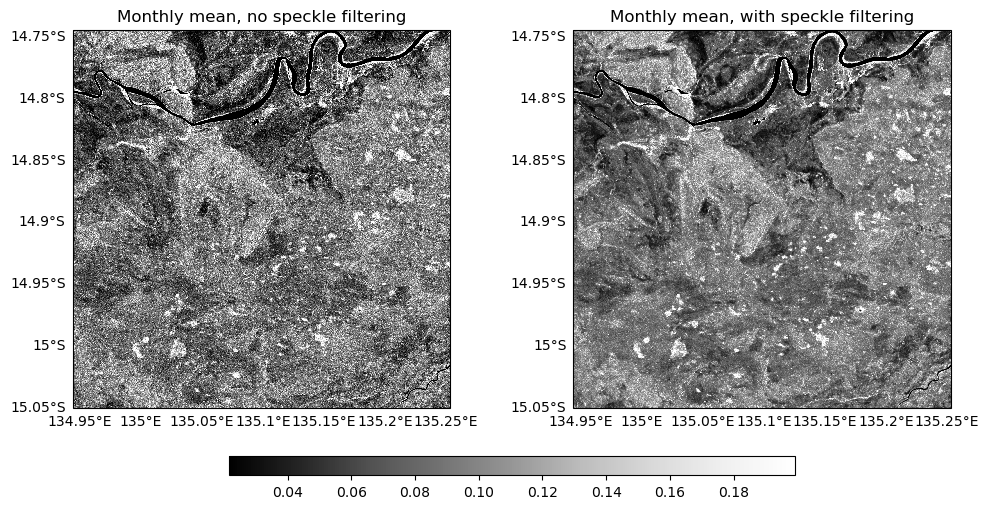

In [215]:
# before and after speckle filtering

fig, axes = plt.subplots(1, 2, figsize=(10, 5), layout="constrained", subplot_kw={"projection": ccrs.epsg(3577)})

ds_s1_timestep = ds_s1_month.isel(month=0)

vmin = float(ds_s1_timestep["VV_gamma0_masked"].quantile(0.02))
vmax = float(ds_s1_timestep["VV_gamma0_masked"].quantile(0.98))

im0 = ds_s1_timestep["VV_gamma0_masked"].plot(
    ax=axes[0], cmap="Greys_r", robust=True, transform=ccrs.epsg(3577),
    add_colorbar=False, vmin=vmin, vmax=vmax
)
axes[0].set_title("Monthly mean, no speckle filtering")
gl0 = axes[0].gridlines(draw_labels=True)
gl0.xlines = False
gl0.ylines = False
gl0.right_labels = False
gl0.top_labels = False

im1 = ds_s1_timestep["VV_gamma0_masked_filtered"].plot(
    ax=axes[1], cmap="Greys_r", robust=True, transform=ccrs.epsg(3577),
    add_colorbar=False, vmin=vmin, vmax=vmax
)
axes[1].set_title("Monthly mean, with speckle filtering")
gl1 = axes[1].gridlines(draw_labels=True)
gl1.xlines = False
gl1.ylines = False
gl1.right_labels = False
gl1.top_labels = False

# Shared colorbar
cbar = fig.colorbar(im1, ax=axes, orientation="horizontal", fraction=0.05, pad=0.07, aspect=30)

plt.show()
# ...existing code...


In [216]:
# make ratio of VV to VH band
ds_s1_month["VH_over_VV_gamma0_masked"] = ds_s1_month["VH_gamma0_masked"] / ds_s1_month["VV_gamma0_masked"]
ds_s1_month["VH_over_VV_gamma0_masked_filtered"] = ds_s1_month["VH_gamma0_masked_filtered"] / ds_s1_month["VV_gamma0_masked_filtered"]


In [217]:
# converting to dB, simplify data array name for future steps

ds_s1_month["VV"] = 10*np.log10(ds_s1_month["VV_gamma0_masked"])
ds_s1_month["VH"] = 10*np.log10(ds_s1_month["VH_gamma0_masked"])
ds_s1_month["VH_over_VV"] = 10*np.log10(ds_s1_month["VH_over_VV_gamma0_masked"])

ds_s1_month["VV_filtered"] = 10*np.log10(ds_s1_month["VV_gamma0_masked_filtered"])
ds_s1_month["VH_filtered"] = 10*np.log10(ds_s1_month["VH_gamma0_masked_filtered"])
ds_s1_month["VH_over_VV_filtered"] = 10*np.log10(ds_s1_month["VH_over_VV_gamma0_masked_filtered"])



In [218]:
# scale data to the 98th percentiles
data_min = ds_s1_month.quantile(0.02)
data_max = ds_s1_month.quantile(0.98)
data_scaled = (ds_s1_month - data_min) / (data_max - data_min)


### Make monthly medians for VV, VH and landsat 8, do PCA on them and try throwing it into a random forest

In [219]:
# rgb(data_scaled, bands=["VV", "VH", "VH_over_VV"], col="month", col_wrap=4, size=4)


## prepare data for PCA and do PCA


In [220]:

ds_s2_month.compute()


Error opening source dataset: s3://dea-public-data/baseline/ga_s2bm_ard_3/53/LMD/2024/06/16_nrt/20240616T021758/ga_s2bm_oa_3-2-1_53LMD_2024-06-16_nrt_s2cloudless-mask.tif
Ignoring Exception: The specified key does not exist.
Error opening source dataset: s3://dea-public-data/baseline/ga_s2bm_ard_3/53/LMD/2024/06/16_nrt/20240616T021758/ga_s2bm_oa_3-2-1_53LMD_2024-06-16_nrt_nbart-contiguity.tif
Ignoring Exception: The specified key does not exist.
Error opening source dataset: s3://dea-public-data/baseline/ga_s2bm_ard_3/53/LMD/2024/06/16_nrt/20240616T021758/ga_s2bm_nbart_3-2-1_53LMD_2024-06-16_nrt_band04.tif
Ignoring Exception: The specified key does not exist.
Error opening source dataset: s3://dea-public-data/baseline/ga_s2am_ard_3/53/LND/2024/06/11_nrt/20240611T024425/ga_s2am_oa_3-2-1_53LND_2024-06-11_nrt_s2cloudless-mask.tif
Error opening source dataset: s3://dea-public-data/baseline/ga_s2am_ard_3/53/LND/2024/06/11_nrt/20240611T024425/ga_s2am_nbart_3-2-1_53LND_2024-06-11_nrt_band04.t

Error opening source dataset: s3://dea-public-data/baseline/ga_s2bm_ard_3/53/LMD/2024/06/16_nrt/20240616T021758/ga_s2bm_nbart_3-2-1_53LMD_2024-06-16_nrt_band08.tif
Ignoring Exception: The specified key does not exist.
Error opening source dataset: s3://dea-public-data/baseline/ga_s2bm_ard_3/53/LND/2024/06/16_nrt/20240616T021758/ga_s2bm_nbart_3-2-1_53LND_2024-06-16_nrt_band08.tif
Ignoring Exception: The specified key does not exist.
Error opening source dataset: s3://dea-public-data/baseline/ga_s2am_ard_3/53/LMD/2024/06/11_nrt/20240611T024425/ga_s2am_nbart_3-2-1_53LMD_2024-06-11_nrt_band08.tif
Ignoring Exception: The specified key does not exist.
Error opening source dataset: s3://dea-public-data/baseline/ga_s2am_ard_3/53/LND/2024/06/11_nrt/20240611T024425/ga_s2am_nbart_3-2-1_53LND_2024-06-11_nrt_band08.tif
Ignoring Exception: The specified key does not exist.
Error opening source dataset: s3://dea-public-data/baseline/ga_s2am_ard_3/53/LMD/2024/06/11_nrt/20240611T024425/ga_s2am_nbart_3-

<xarray.Dataset> Size: 90MB
Dimensions:      (month: 2, y: 1678, x: 1678)
Coordinates:
  * y            (y) float64 13kB -1.567e+06 -1.567e+06 ... -1.601e+06
  * x            (x) float64 13kB 3.193e+05 3.193e+05 ... 3.528e+05 3.528e+05
    spatial_ref  int32 4B 3577
  * month        (month) int64 16B 6 8
Data variables:
    nbart_red    (month, y, x) float32 23MB 906.0 762.5 807.0 ... 805.0 779.0
    nbart_green  (month, y, x) float32 23MB 680.0 636.5 620.0 ... 613.0 557.0
    nbart_blue   (month, y, x) float32 23MB 481.5 435.0 412.5 ... 460.0 425.0
    nbart_nir_1  (month, y, x) float32 23MB 2.362e+03 2.292e+03 ... 1.539e+03
Attributes:
    crs:           EPSG:3577
    grid_mapping:  spatial_ref

In [221]:
pca_xr = data_scaled.drop_vars(["VV_gamma0",
                                "VH_gamma0",
                                "VV_gamma0_masked", 
                                "VH_gamma0_masked", 
                                "mask", 
                                "VV_gamma0_masked_filtered", 
                                "VH_gamma0_masked_filtered", 
                                "VH_over_VV_gamma0_masked", 
                                "VH_over_VV_gamma0_masked_filtered",
                                "VV_filtered",
                                "VH_filtered",
                                "VH_over_VV_filtered"])

pca_xr_filtered = data_scaled.drop_vars(["VV_gamma0", 
                                "VH_gamma0",
                                "VV_gamma0_masked", 
                                "VH_gamma0_masked", 
                                "mask", 
                                "VV_gamma0_masked_filtered", 
                                "VH_gamma0_masked_filtered", 
                                "VH_over_VV_gamma0_masked", 
                                "VH_over_VV_gamma0_masked_filtered",
                                "VV",
                                "VH",
                                "VH_over_VV"])



In [222]:
if 'month' in pca_xr.dims:
    pca_xr = pca_xr.rename({'month': 'time'})
if 'month' in pca_xr_filtered.dims:
    pca_xr_filtered = pca_xr_filtered.rename({'month': 'time'})
if 'month' in ds_s2_month.dims:
    ds_s2_month = ds_s2_month.rename({'month': 'time'})


In [223]:
x_s1 = sklearn_flatten(pca_xr)
pca_s1 = PCA(n_components=3)


In [224]:
pca_s1.fit(x_s1)
print("Relative variance in principal components:", pca_s1.explained_variance_ratio_)


Relative variance in principal components: [5.98243167e-01 4.01756833e-01 6.65969319e-14]


In [225]:
predict_s1 = pca_s1.transform(x_s1)


In [226]:
out_s1 = sklearn_unflatten(predict_s1, pca_xr)
out_s1 = out_s1.to_dataset(dim = out_s1.dims[0]).transpose("time", "y", "x")


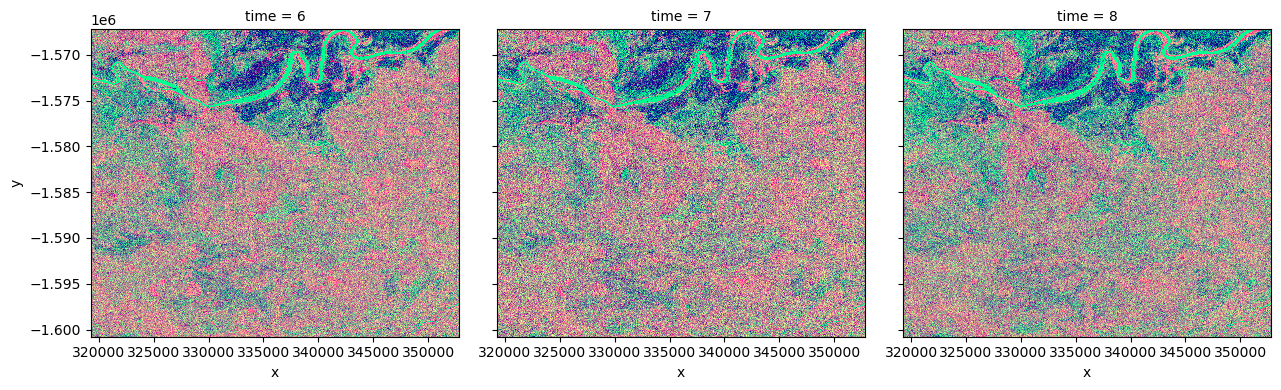

In [227]:
rgb(out_s1, bands=[0, 1, 2], col="time", col_wrap=4, size=4)


## Random sampling to build training dataset from land cover 2.0

In [228]:
lc = dc.load(
    product = "ga_ls_landcover_class_cyear_3",
    measurements = ["level3"],
    resolution = (-30,30), # make this a multiple of 20
    output_crs = "EPSG:3577",
    group_by = "solar_day",
    time = (year),
    geopolygon = geom_bbox.boundary(),
    dask_chunks = {}
)


In [229]:
lc = lc["level3"].squeeze()
lc = lc.where(lc != 255)  # Mask out no data values


In [230]:
# Stratified random samples 
train_points_stratified_random = xr_random_sampling(
    lc, sampling="stratified_random", n=400
)
print('\n')
print('Equal stratified random samples')

# Equal stratified random samples
train_points_equal_stratified_random = xr_random_sampling(
    lc, sampling="equal_stratified_random", n=400
)


Class 111: sampling 7 points
Class 112: sampling 367 points
Class 124: sampling 5 points
Class 216: sampling 8 points
Class 220: sampling 13 points


Equal stratified random samples
Class 111: sampling 80 points
Class 112: sampling 80 points
Class 124: sampling 80 points
Class 216: sampling 80 points
Class 220: sampling 80 points
Class 124: sampling 80 points
Class 216: sampling 80 points
Class 220: sampling 80 points


Error opening source dataset: s3://dea-public-data/baseline/ga_s2am_ard_3/53/LMD/2024/06/11_nrt/20240611T024425/ga_s2am_oa_3-2-1_53LMD_2024-06-11_nrt_s2cloudless-mask.tif
Ignoring Exception: HTTP response code: 404
Error opening source dataset: s3://dea-public-data/baseline/ga_s2bm_ard_3/53/LMD/2024/06/16_nrt/20240616T021758/ga_s2bm_oa_3-2-1_53LMD_2024-06-16_nrt_s2cloudless-mask.tif
Ignoring Exception: HTTP response code: 404
Error opening source dataset: s3://dea-public-data/baseline/ga_s2am_ard_3/53/LMD/2024/06/11_nrt/20240611T024425/ga_s2am_nbart_3-2-1_53LMD_2024-06-11_nrt_band03.tif
Ignoring Exception: HTTP response code: 404
Error opening source dataset: s3://dea-public-data/baseline/ga_s2bm_ard_3/53/LMD/2024/06/16_nrt/20240616T021758/ga_s2bm_nbart_3-2-1_53LMD_2024-06-16_nrt_band02.tif
Ignoring Exception: HTTP response code: 404
Error opening source dataset: s3://dea-public-data/baseline/ga_s2bm_ard_3/53/LMD/2024/06/16_nrt/20240616T021758/ga_s2bm_nbart_3-2-1_53LMD_2024-06-16_nrt_b

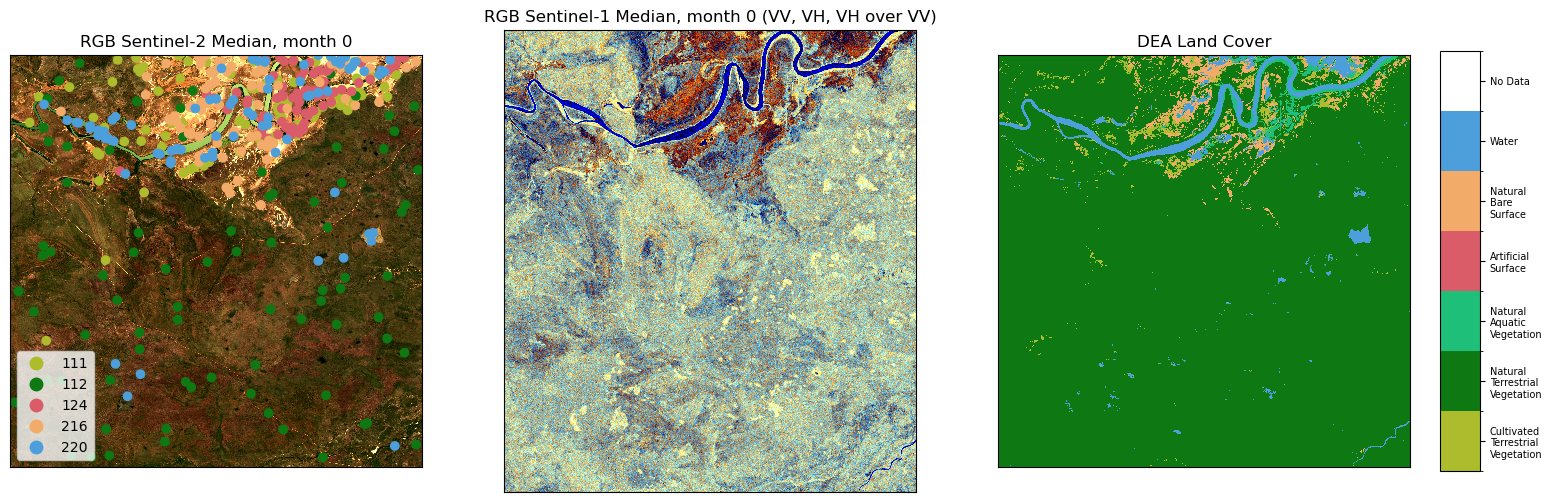

In [231]:
fig, ax = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

colour_scheme = get_colour_scheme("level3")
cmap, norm = lc_colourmap(colour_scheme)

# Trim no-data off the colormap
cmap2=ListedColormap(cmap.colors[:-1])

ds_s2_month[["nbart_red", "nbart_green", "nbart_blue"]].isel(time=0).to_array().plot.imshow(
    robust=True, ax=ax[0], add_labels=False
)
train_points_equal_stratified_random.plot(ax=ax[0], column="class", cmap=cmap2, legend=True, categorical=True)

ax[0].set_title("RGB Sentinel-2 Median, month 0")
ax[0].axes.get_xaxis().set_ticks([])
ax[0].axes.get_yaxis().set_ticks([])

pca_xr[["VV", "VH", "VH_over_VV"]].isel(time=0).to_array().plot.imshow(
    robust=True, ax=ax[1], add_labels=False
)
ax[1].set_title("RGB Sentinel-1 Median, month 0 (VV, VH, VH over VV)")
ax[1].axes.get_xaxis().set_ticks([])
ax[1].axes.get_yaxis().set_ticks([])


im = lc.plot(cmap=cmap, norm=norm, ax=ax[2], add_labels=False, add_colorbar=False)
make_colourbar(fig, ax[2], measurement="level3", labelsize=7, horizontal=False)

ax[2].set_title("DEA Land Cover")
ax[2].axes.get_xaxis().set_ticks([])
ax[2].axes.get_yaxis().set_ticks([]);


## Combine original bands, PCA and GLCM to use for random forrest

In [ ]:
# Random Forest classification using sample points and gridded features
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import pandas as pd

# 1. Extract features at sample points
# Get sample coordinates and class labels
df_samples = train_points_equal_stratified_random[['x', 'y', 'class']].to_dataframe().reset_index(drop=True)

# Extract feature values from pca_xr and out_s1 at sample points
def extract_features_at_points(xr_data, x_coords, y_coords):
    # xr_data: xarray.Dataset or DataArray with dims (time, y, x) or (time, band, y, x)
    # Returns: array of shape (n_points, n_features)
    features = []
    for i in range(len(x_coords)):
        # Find nearest indices
        xi = xr_data.x.sel(x=x_coords[i], method='nearest').values.item()
        yi = xr_data.y.sel(y=y_coords[i], method='nearest').values.item()
        # Extract all time/band features at this location
        vals = []
        for var in xr_data.data_vars:
            vals.extend(xr_data[var].sel(x=xi, y=yi, method='nearest').values.flatten())
        features.append(vals)
    return np.array(features)

# Features from pca_xr
X1 = extract_features_at_points(pca_xr, df_samples['x'], df_samples['y'])
# Features from out_s1 (principal components)
X2 = extract_features_at_points(out_s1, df_samples['x'], df_samples['y'])

# Combine all features
X = np.concatenate([X1, X2], axis=1)
y = df_samples['class'].values

# 2. Train/validation split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 3. Train random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print(f"Validation accuracy: {rf.score(X_val, y_val):.3f}")

# 4. Predict over the full grid
# Flatten all features for the grid (same as before for ML input)
X_grid1 = sklearn_flatten(pca_xr)
X_grid2 = sklearn_flatten(out_s1)
X_grid = np.concatenate([X_grid1, X_grid2], axis=1)

# Predict
y_pred_grid = rf.predict(X_grid)

# 5. Unflatten to raster
raster_pred = sklearn_unflatten(y_pred_grid, pca_xr)

# 6. Store as xarray DataArray with geospatial info
raster_pred = xr.DataArray(raster_pred, dims=pca_xr.dims, coords=pca_xr.coords, name='rf_class')

# Now raster_pred is a gridded raster with geospatial info, ready for plotting or export
raster_pred.plot.imshow(x='x', y='y', col='time', cmap='tab20')
plt.title('Random Forest Classification Result')
plt.show()


KeyError: "['x', 'y'] not in index"